# Hybrid RAG System (LangChain + LangGraph + Ollama)

A RAG system that routes each question to either **vector search** (unstructured docs) or **text-to-SQL** (structured sales data), logs every request to SQLite, and can be evaluated with RAGAS.

Runs entirely on **free, local (to this Colab VM) models via Ollama** — no API key needed.

---
## Step 1: Install and start Ollama inside Colab
This installs Ollama on the Colab VM and starts it as a background server, then pulls the two models we need: a chat model (for routing/SQL-writing/answers) and an embedding model (for vector search).


In [ ]:
!sudo apt-get update -qq && sudo apt-get install -y zstd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 80 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (1,918 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debcon

In [ ]:
# Install Ollama on this Colab machine
!curl -fsSL https://ollama.com/install.sh | sh


>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
import subprocess, time, requests

# nohup + & keeps it running independently of this cell finishing
subprocess.Popen('nohup ollama serve > ollama.log 2>&1 &', shell=True)

# actively wait until the server responds, instead of guessing a sleep time
for i in range(30):
    try:
        r = requests.get('http://localhost:11434')
        if r.status_code == 200:
            print('Ollama server is up.')
            break
    except requests.exceptions.ConnectionError:
        pass
    time.sleep(2)
else:
    print('Ollama did not start in time — check ollama.log for errors.')

Ollama server is up.


In [ ]:
import requests
try:
    requests.get('http://localhost:11434')
    print('Ollama OK')
except requests.exceptions.ConnectionError:
    print('Ollama is DOWN — re-run the start-Ollama cell above')

Ollama OK


In [ ]:
# Start the Ollama server in the background

import subprocess, time

ollama_process = subprocess.Popen(['ollama', 'serve'],

                                   stdout=subprocess.PIPE, stderr=subprocess.PIPE)

time.sleep(5)  # give it a moment to start

print('Ollama server started, PID:', ollama_process.pid)


Ollama server started, PID: 2756


In [ ]:
# Pull the models we'll use (this downloads a few GB, takes a few minutes)

!ollama pull llama3.2

!ollama pull nomic-embed-text

!ollama list




NAME                       ID              SIZE      MODIFIED               
nomic-embed-text:latest    0a109f422b47    274 MB    Less than a second ago    
llama3.2:latest            a80c4f17acd5    2.0 GB    4 seconds ago             


In [ ]:
!pip install -q langchain langgraph langchain-ollama langchain-community networkx matplotlib ragas datasets pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.2/353.2 kB 26.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests

---
## Step 2: Sample data
We need two kinds of data:
- **Unstructured text** (policies/product info) → goes through **vector search**
- **Structured sales data** (an `orders` table in SQLite) → goes through **text-to-SQL**

We'll also create a `query_log` table now, which we'll fill in later as we run real queries.


In [ ]:
import json, sqlite3, random

from datetime import datetime, timedelta



# --- 1. Unstructured knowledge base (VECTOR SEARCH path) ---

knowledge_items = [

    {"text": "Our return policy allows customers to return any item within "

             "30 days of delivery, as long as it is unused and in its "

             "original packaging. Refunds are issued to the original "

             "payment method within 5-7 business days."},

    {"text": "Standard shipping takes 3-5 business days within the country. "

             "Express shipping is available at checkout for an additional "

             "fee and delivers within 1-2 business days."},

    {"text": "The Aurora Wireless Headphones feature active noise "

             "cancellation, 30 hours of battery life, and a comfortable "

             "over-ear design. They are available in black, white, and navy."},

    {"text": "Customers can track their order status by logging into their "

             "account and visiting the 'My Orders' page, or by using the "

             "tracking link sent in their shipping confirmation email."},

    {"text": "The Trailblazer Backpack is made from water-resistant recycled "

             "nylon, has a padded laptop sleeve fitting up to 16 inches, "

             "and includes a hidden anti-theft pocket."},

    {"text": "If an item arrives damaged or defective, customers should "

             "contact support within 48 hours with photos of the damage. "

             "A replacement or full refund will be issued at no extra cost."},

    {"text": "We offer a loyalty program where customers earn 1 point for "

             "every dollar spent. Points can be redeemed for discounts, "

             "with 100 points equal to a $5 reward."},

    {"text": "The Summit Coffee Maker has a 12-cup capacity, a built-in "

             "grinder, and a programmable timer so coffee is ready when "

             "you wake up."},

]



with open('knowledge_base.json', 'w') as f:

    json.dump(knowledge_items, f, indent=2)

print(f'Created knowledge_base.json with {len(knowledge_items)} docs.')



# --- 2. Structured data (TEXT-TO-SQL path) ---

conn = sqlite3.connect('shop.db')

cur = conn.cursor()

cur.execute('DROP TABLE IF EXISTS orders')

cur.execute('''

    CREATE TABLE orders (

        order_id INTEGER PRIMARY KEY,

        product_name TEXT,

        category TEXT,

        quantity INTEGER,

        unit_price REAL,

        order_date TEXT,

        region TEXT

    )

''')



products = [

    ('Aurora Wireless Headphones', 'Electronics', 89.99),

    ('Trailblazer Backpack', 'Accessories', 64.50),

    ('Summit Coffee Maker', 'Home', 45.00),

    ('Everyday Water Bottle', 'Accessories', 18.99),

    ('Pulse Fitness Tracker', 'Electronics', 59.99),

]

regions = ['North', 'South', 'East', 'West']



random.seed(42)

start_date = datetime(2026, 1, 1)

rows = []

for order_id in range(1, 201):

    product_name, category, unit_price = random.choice(products)

    quantity = random.randint(1, 5)

    order_date = (start_date + timedelta(days=random.randint(0, 240))).strftime('%Y-%m-%d')

    region = random.choice(regions)

    rows.append((order_id, product_name, category, quantity, unit_price, order_date, region))



cur.executemany('INSERT INTO orders VALUES (?, ?, ?, ?, ?, ?, ?)', rows)

conn.commit()



cur.execute('SELECT COUNT(*), ROUND(SUM(quantity * unit_price), 2) FROM orders')

count, total_revenue = cur.fetchone()

print(f'Created shop.db orders table: {count} rows, ${total_revenue} total revenue.')



# --- 3. Logging table ---

cur.execute('''

    CREATE TABLE IF NOT EXISTS query_log (

        log_id INTEGER PRIMARY KEY AUTOINCREMENT,

        question TEXT,

        route TEXT,

        context TEXT,

        answer TEXT,

        latency_seconds REAL,

        created_at TEXT

    )

''')

conn.commit()

conn.close()

print('Created query_log table (empty for now).')


Created knowledge_base.json with 8 docs.
Created shop.db orders table: 200 rows, $33974.43 total revenue.
Created query_log table (empty for now).


In [ ]:
# Quick sanity check of what we just created

import sqlite3, json



conn = sqlite3.connect('shop.db')

cur = conn.cursor()

cur.execute('SELECT * FROM orders LIMIT 5')

for row in cur.fetchall():

    print(row)

conn.close()



with open('knowledge_base.json') as f:

    kb = json.load(f)

print()

print('Sample doc:', kb[0]['text'][:100], '...')


(1, 'Aurora Wireless Headphones', 'Electronics', 1, 89.99, '2026-07-09', 'East')
(2, 'Trailblazer Backpack', 'Accessories', 2, 64.5, '2026-02-05', 'North')
(3, 'Pulse Fitness Tracker', 'Electronics', 1, 59.99, '2026-06-01', 'West')
(4, 'Aurora Wireless Headphones', 'Electronics', 1, 89.99, '2026-01-24', 'South')
(5, 'Trailblazer Backpack', 'Accessories', 5, 64.5, '2026-06-04', 'North')

Sample doc: Our return policy allows customers to return any item within 30 days of delivery, as long as it is u ...


---
**Next: Step 3** — we'll define the shared `State`, and write the **router** that decides whether a question needs vector search or SQL. Run everything above first (the Ollama pulls take a few minutes), then let's continue.


In [ ]:
from typing_extensions import TypedDict
from typing import List
from langchain_core.documents import Document

class State(TypedDict):
    question: str          # the user's question
    route: str              # 'vector' or 'sql' -- decided by the router
    context: List[Document] # retrieved chunks (vector path) or query result (sql path)
    sql_query: str           # the generated SQL, if we took the sql path (handy for debugging)
    answer: str              # the final answer shown to the user

In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model='llama3.2', temperature=0)

ROUTER_PROMPT = """You are a router that decides how to answer a question about an online shop.

Reply with exactly one word, nothing else: 'sql' or 'vector'.

Rule of thumb: if the answer would be a NUMBER calculated from many rows (a total, count,
sum, or average), use 'sql'. If the answer is a FACT written in a policy or product
description (even if it mentions a number, like "30 hours" or "3-5 days"), use 'vector'.

Examples:
Question: How long does standard shipping take?
Answer: vector
(This is a written policy fact, not something to calculate from a database.)

Question: How many hours of battery life do the Aurora Wireless Headphones have?
Answer: vector
(This is a written product spec, not a database calculation.)

Question: How much total revenue came from the West region?
Answer: sql
(This requires summing rows in the orders table.)

Question: How many orders were placed in the South region?
Answer: sql
(This requires counting rows in the orders table.)

Question: What is your return policy?
Answer: vector
(This is written policy text.)

Now classify this question. Reply with ONLY 'sql' or 'vector', nothing else.

Question: {question}
Answer:"""

def classify(state: State):
    prompt = ROUTER_PROMPT.format(question=state['question'])
    response = llm.invoke([{'role': 'user', 'content': prompt}])
    route = response.content.strip().lower()
    route = 'sql' if 'sql' in route else 'vector'
    return {'route': route}

In [ ]:
test_questions = [
    'What is your return policy?',
    'How much total revenue came from the North region?',
    'Does the Aurora Wireless Headphones come in white?',
    'How many orders were placed for the Summit Coffee Maker?',
]

for q in test_questions:
    result = classify({'question': q})
    print(f"{result['route']:>7}  <-  {q}")

 vector  <-  What is your return policy?
    sql  <-  How much total revenue came from the North region?
 vector  <-  Does the Aurora Wireless Headphones come in white?
    sql  <-  How many orders were placed for the Summit Coffee Maker?


In [ ]:
import json
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

with open('knowledge_base.json') as f:
    knowledge_items = json.load(f)

docs = [Document(page_content=item['text']) for item in knowledge_items]

embeddings = OllamaEmbeddings(model='nomic-embed-text')
vector_store = InMemoryVectorStore(embeddings)
vector_store.add_documents(docs)

print(f'Embedded and stored {len(docs)} documents.')

Embedded and stored 8 documents.


In [ ]:
def vector_retrieve(state: State):
    results = vector_store.similarity_search(state['question'], k=5)
    return {'context': results}

# quick test on its own
test_result = vector_retrieve({'question': 'What is your return policy?'})
for doc in test_result['context']:
    print('-', doc.page_content[:90], '...')

- Our return policy allows customers to return any item within 30 days of delivery, as long  ...
- If an item arrives damaged or defective, customers should contact support within 48 hours  ...
- We offer a loyalty program where customers earn 1 point for every dollar spent. Points can ...
- Customers can track their order status by logging into their account and visiting the 'My  ...
- The Trailblazer Backpack is made from water-resistant recycled nylon, has a padded laptop  ...


In [ ]:
import sqlite3
import re

SQL_PROMPT = """You write SQLite queries. The database has one table:

orders(order_id INTEGER, product_name TEXT, category TEXT, quantity INTEGER,
       unit_price REAL, order_date TEXT, region TEXT)

Write ONE SQLite SELECT query that answers the question below.
Reply with ONLY the SQL query, no explanation, no markdown formatting, no semicolon.

Question: {question}
SQL query:"""

def sql_retrieve(state: State):
    prompt = SQL_PROMPT.format(question=state['question'])
    response = llm.invoke([{'role': 'user', 'content': prompt}])
    sql_query = response.content.strip()
    # strip markdown code fences if the model added them anyway
    sql_query = re.sub(r'^```sql|^```|```$', '', sql_query, flags=re.MULTILINE).strip()

    # safety net: only allow SELECT queries -- never let the LLM run anything else
    if not sql_query.lower().startswith('select'):
        return {'sql_query': sql_query, 'context': [Document(page_content='Could not generate a safe query.')]}

    conn = sqlite3.connect('shop.db')
    try:
        cur = conn.cursor()
        cur.execute(sql_query)
        columns = [d[0] for d in cur.description]
        rows = cur.fetchall()
        result_text = ', '.join(columns) + '\n' + '\n'.join(str(r) for r in rows[:20])
    except Exception as e:
        result_text = f'Query failed: {e}'
    finally:
        conn.close()

    return {'sql_query': sql_query, 'context': [Document(page_content=result_text)]}

In [ ]:
# quick test on its own
test_result = sql_retrieve({'question': 'What is the total revenue from the North region?'})
print('Generated SQL:', test_result['sql_query'])
print('Result:')
print(test_result['context'][0].page_content)

Generated SQL: SELECT SUM(unit_price * quantity) FROM orders WHERE region = 'North'
Result:
SUM(unit_price * quantity)
(10101.779999999997,)


In [ ]:
GENERATE_PROMPT = """You are a helpful shop assistant. Use the context below to answer
the question. If the context doesn't contain enough information, say so clearly.
Do not make up numbers or facts that aren't in the context.

Question: {question}

Context:
{context}

Answer:"""

def generate(state: State):
    context_text = '\n\n'.join(doc.page_content for doc in state['context'])
    prompt = GENERATE_PROMPT.format(question=state['question'], context=context_text)
    response = llm.invoke([{'role': 'user', 'content': prompt}])
    return {'answer': response.content}

In [ ]:
import time
import sqlite3
from datetime import datetime

def log_to_db(state: State, latency_seconds: float):
    context_text = '\n\n'.join(doc.page_content for doc in state['context'])
    conn = sqlite3.connect('shop.db')
    cur = conn.cursor()
    cur.execute(
        'INSERT INTO query_log (question, route, context, answer, latency_seconds, created_at) '
        'VALUES (?, ?, ?, ?, ?, ?)',
        (state['question'], state['route'], context_text, state['answer'],
         latency_seconds, datetime.now().isoformat())
    )
    conn.commit()
    conn.close()

In [ ]:
from langgraph.graph import START, END, StateGraph

graph_builder = StateGraph(State)

graph_builder.add_node('classify', classify)
graph_builder.add_node('vector_retrieve', vector_retrieve)
graph_builder.add_node('sql_retrieve', sql_retrieve)
graph_builder.add_node('generate', generate)

graph_builder.add_edge(START, 'classify')

# this is the branching logic: look at state['route'] and go to the matching node
graph_builder.add_conditional_edges(
    'classify',
    lambda state: state['route'],
    {'vector': 'vector_retrieve', 'sql': 'sql_retrieve'}
)

graph_builder.add_edge('vector_retrieve', 'generate')
graph_builder.add_edge('sql_retrieve', 'generate')
graph_builder.add_edge('generate', END)

graph = graph_builder.compile()
print('Graph compiled successfully.')

Graph compiled successfully.


In [ ]:
def ask(question: str):
    start = time.time()
    result = graph.invoke({'question': question})
    latency = time.time() - start
    log_to_db(result, latency)
    print(f"Q: {question}")
    print(f"Route taken: {result['route']}  ({latency:.2f}s)")
    print(f"A: {result['answer']}")
    print('-' * 80)


In [ ]:
ask('What is your return policy?')

Q: What is your return policy?
Route taken: vector  (58.96s)
A: Our return policy allows customers to return any item within 30 days of delivery, as long as it is unused and in its original packaging. Refunds are issued to the original payment method within 5-7 business days.

If an item arrives damaged or defective, customers should contact support within 48 hours with photos of the damage. A replacement or full refund will be issued at no extra cost.

We do not have a specific policy for returns outside of the 30-day window, as the context does not provide information on this.
--------------------------------------------------------------------------------


In [ ]:
ask('How much total revenue came from the East region?')

Q: How much total revenue came from the East region?
Route taken: sql  (35.13s)
A: The total revenue from the East region is not explicitly stated in the context. The context only shows a calculation result, which is the total revenue, but it doesn't provide the unit price or quantity values used in the calculation.
--------------------------------------------------------------------------------


In [ ]:
ask('What features does the Trailblazer Backpack have?')

Q: What features does the Trailblazer Backpack have?
Route taken: vector  (36.71s)
A: Unfortunately, the context doesn't mention the Trailblazer Backpack at all. It only talks about the Summit Coffee Maker and the Aurora Wireless Headphones. Therefore, I don't have enough information to answer your question about the Trailblazer Backpack's features.
--------------------------------------------------------------------------------


In [ ]:
ask('How many Pulse Fitness Trackers were sold?')

Q: How many Pulse Fitness Trackers were sold?
Route taken: sql  (35.00s)
A: I don't have enough information to accurately answer the question about the number of Pulse Fitness Trackers sold. The context appears to be a list of quantities, but it's not clear what they represent or how they relate to Pulse Fitness Trackers.
--------------------------------------------------------------------------------


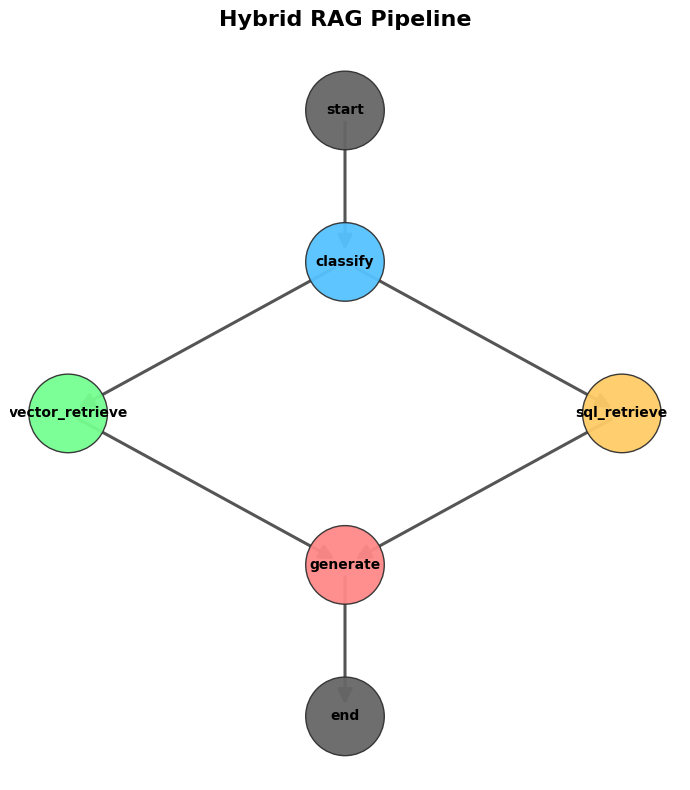

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_pipeline():
    G = nx.DiGraph()
    nodes = ['start', 'classify', 'vector_retrieve', 'sql_retrieve', 'generate', 'end']
    edges = [
        ('start', 'classify'),
        ('classify', 'vector_retrieve'),
        ('classify', 'sql_retrieve'),
        ('vector_retrieve', 'generate'),
        ('sql_retrieve', 'generate'),
        ('generate', 'end'),
    ]
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # manual layout so the branch is visually clear (top-to-bottom flow)
    pos = {
        'start': (1, 4),
        'classify': (1, 3),
        'vector_retrieve': (0, 2),
        'sql_retrieve': (2, 2),
        'generate': (1, 1),
        'end': (1, 0),
    }

    node_colors = {
        'start': '#666666', 'end': '#666666',
        'classify': '#56c2ff',
        'vector_retrieve': '#75ff90', 'sql_retrieve': '#ffcc66',
        'generate': '#ff8888',
    }
    colors = [node_colors[n] for n in G.nodes()]

    plt.figure(figsize=(7, 8))
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=3200,
                            edgecolors='#303030', alpha=0.95)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=22,
                            width=2.2, edge_color='#555')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    plt.title('Hybrid RAG Pipeline', fontsize=16, fontweight='bold', pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_pipeline()

In [ ]:
benchmark = [
    {'question': 'What is your return policy?',
     'ground_truth': 'Items can be returned within 30 days if unused and in original packaging, refunded within 5-7 business days.'},
    {'question': 'How long does standard shipping take?',
     'ground_truth': 'Standard shipping takes 3-5 business days.'},
    {'question': 'What should I do if my item arrives damaged?',
     'ground_truth': 'Contact support within 48 hours with photos; a replacement or full refund is issued.'},
    {'question': 'How many hours of battery life do the Aurora Wireless Headphones have?',
     'ground_truth': 'The Aurora Wireless Headphones have 30 hours of battery life.'},
    {'question': 'How much total revenue came from the West region?',
     'ground_truth': None},
    {'question': 'How many orders were placed in the South region?',
     'ground_truth': None},
]

In [ ]:
import requests
try:
    requests.get('http://localhost:11434')
    print('Ollama OK')
except requests.exceptions.ConnectionError:
    print('Ollama is DOWN — wait a few seconds and check again')

Ollama OK


In [ ]:
eval_rows = []

for item in benchmark:
    result = graph.invoke({'question': item['question']})
    latency = 0.0
    log_to_db(result, latency)

    contexts = [doc.page_content for doc in result['context']]
    ground_truth = item['ground_truth'] if item['ground_truth'] else contexts[0]

    eval_rows.append({
        'question': item['question'],
        'contexts': contexts,
        'answer': result['answer'],
        'ground_truth': ground_truth,
    })
    print(f"Done: {item['question']}")

Done: What is your return policy?
Done: How long does standard shipping take?
Done: What should I do if my item arrives damaged?
Done: How many hours of battery life do the Aurora Wireless Headphones have?
Done: How much total revenue came from the West region?
Done: How many orders were placed in the South region?


In [ ]:
!pip install -q google-cloud-aiplatform langchain-google-vertexai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.5/356.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 113.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0

In [60]:
import re

def score_with_llm(prompt: str) -> float:
    """Ask the LLM to output a single score between 0 and 1."""
    response = llm.invoke([{'role': 'user', 'content': prompt}])
    match = re.search(r'0?\.\d+|\b[01]\b', response.content)
    return float(match.group()) if match else 0.5

FAITHFULNESS_PROMPT = """Context:
{context}

Answer:
{answer}

On a scale of 0.0 to 1.0, how much of the Answer is directly supported by the Context
(no made-up facts)? Reply with ONLY a number between 0 and 1, nothing else."""

RELEVANCY_PROMPT = """Question:
{question}

Answer:
{answer}

On a scale of 0.0 to 1.0, how directly does the Answer address the Question?
Reply with ONLY a number between 0 and 1, nothing else."""

PRECISION_PROMPT = """Question:
{question}

Retrieved context:
{context}

On a scale of 0.0 to 1.0, how relevant is this retrieved context to answering the question?
Reply with ONLY a number between 0 and 1, nothing else."""

results = []
for row in eval_rows:
    context_text = '\n\n'.join(row['contexts'])
    faithfulness_score = score_with_llm(FAITHFULNESS_PROMPT.format(context=context_text, answer=row['answer']))
    relevancy_score = score_with_llm(RELEVANCY_PROMPT.format(question=row['question'], answer=row['answer']))
    precision_score = score_with_llm(PRECISION_PROMPT.format(question=row['question'], context=context_text))

    results.append({
        'question': row['question'],
        'faithfulness': faithfulness_score,
        'answer_relevancy': relevancy_score,
        'context_precision': precision_score,
    })
    print(f"Scored: {row['question']}")

Scored: What is your return policy?
Scored: How long does standard shipping take?
Scored: What should I do if my item arrives damaged?
Scored: How many hours of battery life do the Aurora Wireless Headphones have?
Scored: How much total revenue came from the West region?
Scored: How many orders were placed in the South region?


In [59]:
scores_df = results  # plain list of dicts, no pandas needed

for row in scores_df:
    print(f"{row['question'][:55]:<55} faithfulness={row['faithfulness']:.2f}  relevancy={row['answer_relevancy']:.2f}  precision={row['context_precision']:.2f}")

avg_faithfulness = sum(r['faithfulness'] for r in scores_df) / len(scores_df)
avg_relevancy = sum(r['answer_relevancy'] for r in scores_df) / len(scores_df)
avg_precision = sum(r['context_precision'] for r in scores_df) / len(scores_df)

print()
print(f'Average faithfulness:      {avg_faithfulness:.2%}')
print(f'Average answer relevancy:  {avg_relevancy:.2%}')
print(f'Average context precision: {avg_precision:.2%}')

What is your return policy?                             faithfulness=0.80  relevancy=0.80  precision=0.80
How long does standard shipping take?                   faithfulness=0.50  relevancy=0.80  precision=0.80
What should I do if my item arrives damaged?            faithfulness=0.80  relevancy=0.80  precision=0.80
How many hours of battery life do the Aurora Wireless H faithfulness=0.50  relevancy=0.50  precision=0.80
How much total revenue came from the West region?       faithfulness=0.50  relevancy=0.50  precision=0.50
How many orders were placed in the South region?        faithfulness=0.50  relevancy=0.80  precision=0.80

Average faithfulness:      60.00%
Average answer relevancy:  70.00%
Average context precision: 75.00%


In [61]:
import csv, sqlite3

conn = sqlite3.connect('shop.db')
cur = conn.cursor()
cur.execute('SELECT * FROM query_log')
rows = cur.fetchall()
columns = [d[0] for d in cur.description]
conn.close()

with open('query_log_export.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(columns)
    writer.writerows(rows)

with open('ragas_scores_export.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['question', 'faithfulness', 'answer_relevancy', 'context_precision'])
    for row in scores_df:
        writer.writerow([row['question'], row['faithfulness'], row['answer_relevancy'], row['context_precision']])

print('Exported query_log_export.csv and ragas_scores_export.csv')

Exported query_log_export.csv and ragas_scores_export.csv
